### What is the distribution of restaurants per location?

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import geopandas as gpd

from shapely.geometry import Point
import contextily as ctx


In [2]:
conn=duckdb.connect('my_database.duckdb')

In [3]:
query_delivero = """
    SELECT 
        loc.name,
        loc.latitude,
        loc.longitude,
        COUNT(resto.id) AS num_restaurants
    FROM deliveroo_restaurants AS resto
    JOIN deliveroo_locations_to_restaurants AS loc_to_resto
        ON resto.id = loc_to_resto.restaurant_id
    JOIN deliveroo_locations AS loc
        ON loc.id = loc_to_resto.location_id
    GROUP BY loc.name, loc.latitude, loc.longitude
    HAVING loc.name != '0'
    ORDER BY num_restaurants DESC
"""
df = conn.execute(query_delivero).fetchdf()

gdf = gpd.GeoDataFrame(df, 
                       geometry=gpd.points_from_xy(df.longitude, df.latitude), 
                       crs="EPSG:4326")


belgium = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/BEL.geo.json")

gdf.explore(
    column="num_restaurants",  
    tooltip=["name", "num_restaurants"],  
    popup=True 
)


In [4]:
resto_deliveroo=conn.execute(
""" 
    SELECT COUNT(resto.id)  AS num_restaurants ,  loc.name
    FROM deliveroo_restaurants as resto
    JOIN deliveroo_locations_to_restaurants as loc_to_resto
        ON resto.id=loc_to_resto.restaurant_id
    JOIN deliveroo_locations as loc
        ON loc.id=loc_to_resto.location_id
    GROUP By loc.name
    ORDER BY  COUNT(resto.id) desc;
"""
).fetch_df()
resto_deliveroo

,num_restaurants,name
0,10272,0
1,1599,Sint-Pauluskerk
2,1420,Sint-Willibrorduskerk
3,1276,Sint-Annakerk
4,1246,Sint-Catharinakerk
...,...,...
336,1,Sint-Stevenskerk
337,1,Sint-Ulrikkerk
338,1,Wolfshagenkapel
339,1,Onze-Lieve-Vrouw-ten-Hemel-Opgenomenkerk


In [5]:
resto_deliveroo_filter=resto_deliveroo[resto_deliveroo['name']!='0']
resto_deliveroo_filter

,num_restaurants,name
1,1599,Sint-Pauluskerk
2,1420,Sint-Willibrorduskerk
3,1276,Sint-Annakerk
4,1246,Sint-Catharinakerk
5,1097,Heilig-Hartkerk
...,...,...
336,1,Sint-Stevenskerk
337,1,Sint-Ulrikkerk
338,1,Wolfshagenkapel
339,1,Onze-Lieve-Vrouw-ten-Hemel-Opgenomenkerk


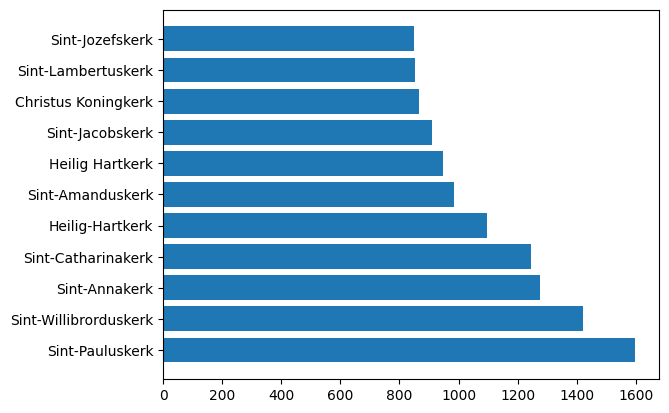

In [6]:
plt.barh(resto_deliveroo_filter['name'][:11], resto_deliveroo_filter['num_restaurants'][:11])
plt.show()

In [7]:
query_takeaway = """
SELECT
    loc.name,
    loc.latitude  AS latitude,
    loc.longitude  AS longitude,
    COUNT(resto.primarySlug) AS num_restaurants
FROM takeaway_restaurants AS resto
JOIN takeaway_locations_to_restaurants AS loc_to_resto
    ON resto.primarySlug = loc_to_resto.restaurant_id
JOIN takeaway_locations AS loc
    ON loc.ID = loc_to_resto.location_id
WHERE loc.name != '0'
GROUP BY loc.name,
        loc.latitude ,
        loc.longitude 
ORDER BY num_restaurants DESC
"""

df_takeaway = conn.execute(query_takeaway).fetchdf()


df_takeaway['geometry'] = df_takeaway.apply(lambda row: f"POINT({row['longitude']} {row['latitude']})", axis=1)


gdf = gpd.GeoDataFrame(
    df_takeaway,
    geometry=gpd.GeoSeries.from_wkt(df_takeaway['geometry']),
    crs="EPSG:4326"
)



belgium = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/BEL.geo.json")


gdf.explore(
    column="num_restaurants",  
    tooltip=["name", "num_restaurants"],  
    popup=True  
)



In [8]:
resto_takeaway=conn.execute(
""" 
    SELECT COUNT(resto.primarySlug)  AS num_restaurants,  loc.name
    FROM takeaway_restaurants as resto
    JOIN takeaway_locations_to_restaurants as loc_to_resto
        ON resto.primarySlug=loc_to_resto.restaurant_id
    JOIN takeaway_locations as loc
        ON loc.ID=loc_to_resto.location_id
    GROUP By loc.name
    ORDER BY  COUNT(resto.primarySlug) desc;
"""
).fetch_df()
resto_takeaway

,num_restaurants,name
0,18849,0
1,4721,Sint-Martinuskerk
2,2458,Sint-Jozefkerk
3,2331,Sint-Lambertuskerk
4,2205,Sint-Amanduskerk
...,...,...
919,1,Sint-Rectrudiskerk
920,1,Gemeentehuis Lo-Reninge
921,1,Sint-Victorkerk
922,1,Sint-Amatuskerk


In [9]:
resto_takeaway_filter=resto_takeaway[resto_takeaway['name']!='0']

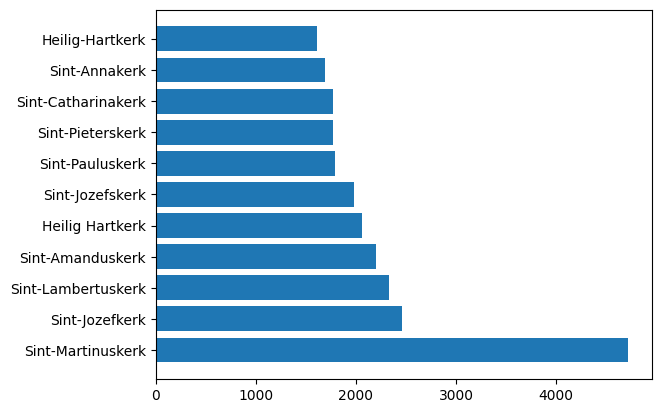

In [10]:
plt.barh(resto_takeaway_filter['name'][:11], resto_takeaway_filter['num_restaurants'][:11])
plt.show()

In [11]:
query_ubereats = """
SELECT
    loc.name,
    loc.latitude  AS latitude,
    loc.longitude  AS longitude,
    COUNT(resto.id) AS num_restaurants
FROM ubereats_restaurants as resto
JOIN ubereats_locations_to_restaurants as loc_to_resto
    ON resto.id=loc_to_resto.restaurant_id
JOIN ubereats_locations as loc
    ON loc.id=loc_to_resto.location_id 
WHERE  loc.name != '0'
GROUP BY loc.name,
        loc.latitude,
        loc.longitude 
ORDER BY num_restaurants DESC

"""

df_ubereats = conn.execute(query_ubereats).fetchdf()


df_ubereats['geometry'] = df_ubereats.apply(lambda row: f"POINT({row['longitude']} {row['latitude']})", axis=1)


gdf = gpd.GeoDataFrame(
    df_ubereats,
    geometry=gpd.GeoSeries.from_wkt(df_ubereats['geometry']),
    crs="EPSG:4326"
)




belgium = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/BEL.geo.json")


gdf.explore(
    column="num_restaurants", 
    tooltip=["name", "num_restaurants"],  
    popup=True  
)



In [12]:
resto_ubereats=conn.execute(
    """ 
        SELECT COUNT(resto.id) AS num_restaurants, loc.name
        FROM ubereats_restaurants as resto
        JOIN ubereats_locations_to_restaurants as loc_to_resto
                ON resto.id=loc_to_resto.restaurant_id
        JOIN ubereats_locations as loc
                ON loc.id=loc_to_resto.location_id 
        GROUP BY loc.name
        ORDER BY num_restaurants desc;
        
""").fetch_df()

resto_ubereats

,num_restaurants,name
0,8801,0
1,1149,Sint-Martinuskerk
2,1135,Sint-Pauluskerk
3,1103,Sint-Willibrorduskerk
4,1031,Sint-Amanduskerk
...,...,...
784,1,Mariahal
785,1,Muggenbergkapel
786,1,Onze-Lieve-Vrouw van Troost ter Warande
787,1,Sint-Onkomenakerk


In [13]:
resto_ubereats_filter=resto_ubereats[resto_ubereats['name']!='0']

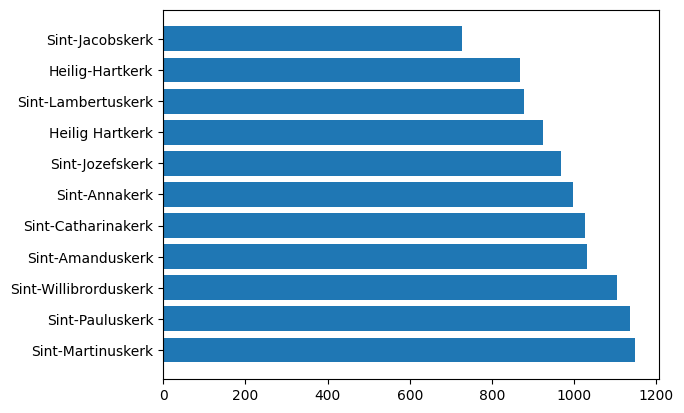

In [14]:
plt.barh(resto_ubereats_filter['name'][:11], resto_ubereats_filter['num_restaurants'][:11])
plt.show()

In [15]:
# Mantengo il tuo codice originale
query_ubereats = """
SELECT
    loc.name,
    loc.latitude  AS latitude,
    loc.longitude  AS longitude,
    COUNT(resto.id) AS num_restaurants
FROM ubereats_restaurants as resto
JOIN ubereats_locations_to_restaurants as loc_to_resto
    ON resto.id=loc_to_resto.restaurant_id
JOIN ubereats_locations as loc
    ON loc.id=loc_to_resto.location_id 
WHERE  loc.name != '0'
GROUP BY loc.name,
        loc.latitude,
        loc.longitude 
ORDER BY num_restaurants DESC

"""

df_ubereats = conn.execute(query_ubereats).fetchdf()

# Aggiungi la colonna 'geometry' in formato WKT (Well-Known Text)
df_ubereats['geometry'] = df_ubereats.apply(lambda row: f"POINT({row['longitude']} {row['latitude']})", axis=1)

# Crea il GeoDataFrame da df
gdf = gpd.GeoDataFrame(
    df_ubereats,
    geometry=gpd.GeoSeries.from_wkt(df_ubereats['geometry']),
    crs="EPSG:4326"
)



# Scarica i confini del Belgio
belgium = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/BEL.geo.json")

# Crea la mappa con i tuoi dati originali
m = gdf.explore(
    column="num_restaurants",  # Colora punti in base al numero di ristoranti
    tooltip=["name", "num_restaurants"],  # Info al passaggio del mouse
    popup=True  # Mostra dettagli al click
)

m

In [19]:
resto_deliveroo['platform'] = 'Deliveroo'
resto_takeaway['platform'] = 'Takeaway'
resto_ubereats['platform'] = 'UberEats'


all_restaurants = pd.concat([resto_deliveroo, resto_takeaway, resto_ubereats])


all_restaurants_grouped = all_restaurants.groupby( 'platform').sum().reset_index()
all_restaurants_grouped

,platform,num_restaurants,name
0,Deliveroo,80825,0Sint-PauluskerkSint-WillibrorduskerkSint-Anna...
1,Takeaway,157809,0Sint-MartinuskerkSint-JozefkerkSint-Lambertus...
2,UberEats,70626,0Sint-MartinuskerkSint-PauluskerkSint-Willibro...


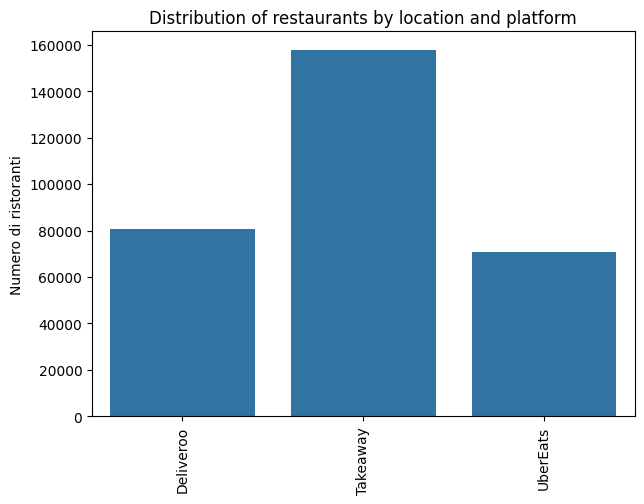

In [20]:
plt.figure(figsize=(7, 5))
sns.barplot(x='platform', y='num_restaurants', data=all_restaurants_grouped)
plt.xticks(rotation=90)
plt.title('Distribution of restaurants by location and platform')
plt.xlabel('')
# plt.xlabel('Località')
plt.ylabel('Numero di ristoranti')
plt.show()

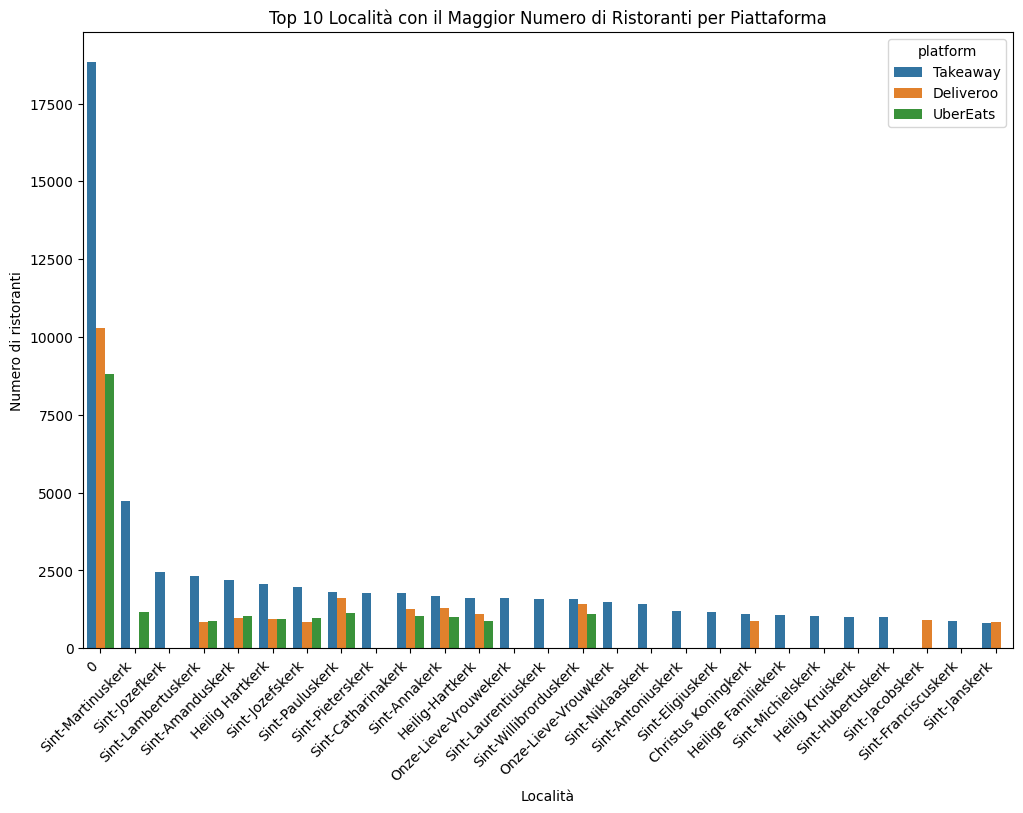

In [ ]:
top_10_restaurants = all_restaurants_grouped.sort_values(by='num_restaurants', ascending=False).head(50)


plt.figure(figsize=(12, 8))
sns.barplot(x='name', y='num_restaurants', hue='platform', data=top_10_restaurants)


plt.xticks(rotation=45, ha="right")  
plt.title('Top 10 Locations with the Highest Number of Restaurants per Platform')
plt.xlabel('Località')
plt.ylabel('Numero di ristoranti')
plt.show()


In [ ]:
conn.close()